In [1]:
import numpy as np
import pandas as pd

def generate_dataset(N=50000, seed=42):
    np.random.seed(seed)

    years_experience = np.clip(np.random.normal(5, 2, N), 0, 20)
    education_score = np.clip(np.random.normal(70, 10, N), 40, 100)
    technical_test_score = np.clip(np.random.normal(65, 15, N), 0, 100)
    communication_score = np.clip(np.random.normal(60, 12, N), 0, 100)
    salary_expectation = np.random.lognormal(10, 0.4, N) / 1000

    has_internship = np.random.choice([0,1], N, p=[0.4,0.6])
    has_leadership = np.random.choice([0,1], N, p=[0.7,0.3])

    job_domains = {
        "Software": ["Data Scientist", "Backend Developer"],
        "Finance": ["Financial Analyst", "Risk Analyst"],
        "Healthcare": ["Healthcare Consultant"],
        "Marketing": ["Digital Marketer"],
        "Mechanical": ["Mechanical Engineer"]
    }

    domain_list = list(job_domains.keys())
    selected_domain = np.random.choice(domain_list, N)
    job_role = [np.random.choice(job_domains[d]) for d in selected_domain]

    logit = (
        0.03 * technical_test_score +
        0.02 * communication_score +
        0.5 * has_internship +
        0.4 * has_leadership +
        0.015 * years_experience -
        0.002 * salary_expectation +
        np.random.normal(0, 2, N)
    )

    prob = 1 / (1 + np.exp(-logit))
    selected = np.where(prob > np.percentile(prob, 70), 1, 0)

    df = pd.DataFrame({
        "years_experience": years_experience,
        "education_score": education_score,
        "technical_test_score": technical_test_score,
        "communication_score": communication_score,
        "salary_expectation": salary_expectation,
        "has_internship": has_internship,
        "has_leadership": has_leadership,
        "job_role": job_role,
        "selected": selected
    })

    df.to_csv("job.csv", index=False)
    return df

df = generate_dataset()

(50000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   years_experience      50000 non-null  float64
 1   education_score       50000 non-null  float64
 2   technical_test_score  50000 non-null  float64
 3   communication_score   50000 non-null  float64
 4   salary_expectation    50000 non-null  float64
 5   has_internship        50000 non-null  int64  
 6   has_leadership        50000 non-null  int64  
 7   job_role              50000 non-null  object 
 8   selected              50000 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 3.4+ MB
None
       years_experience  education_score  technical_test_score  \
count      50000.000000     50000.000000          50000.000000   
mean           5.003546        70.023010             65.006087   
std            1.987986         9.993515             14

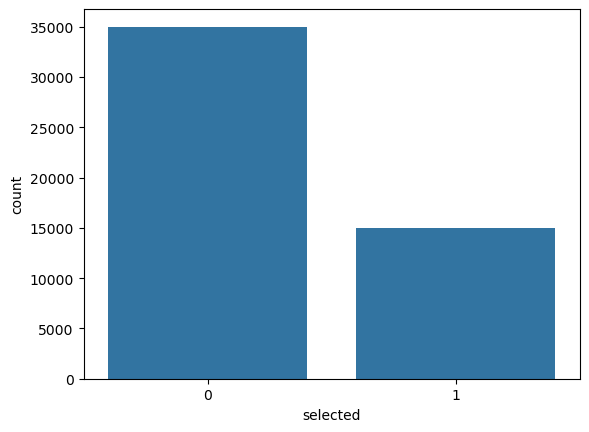

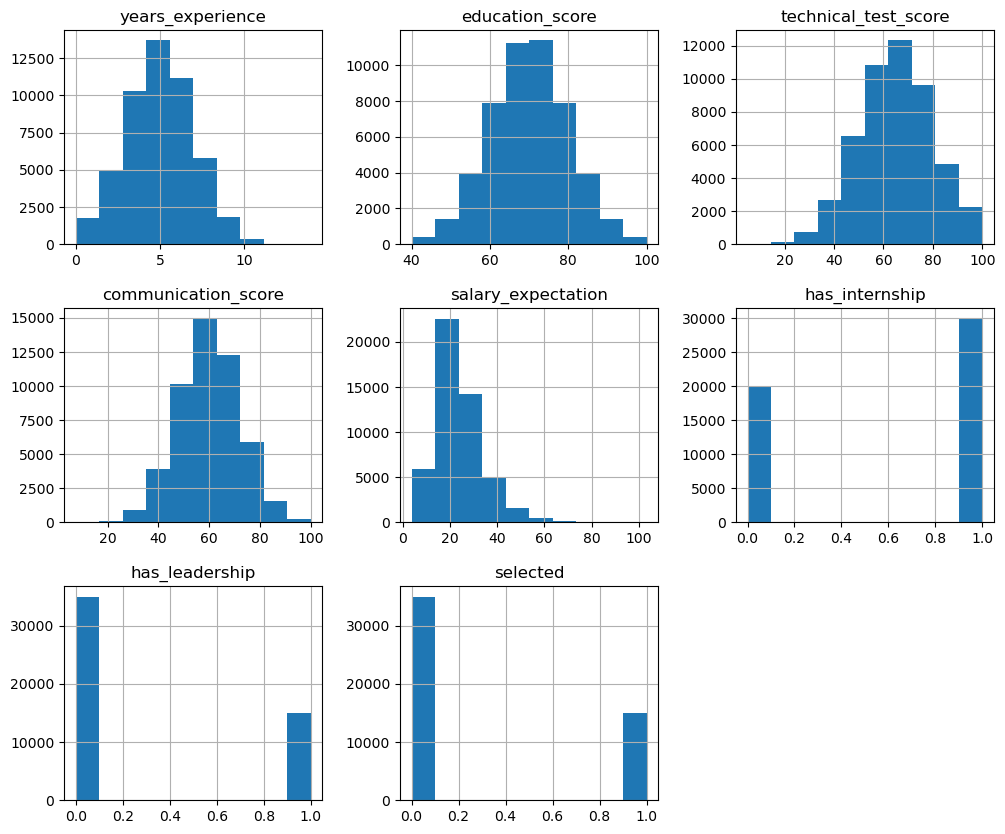

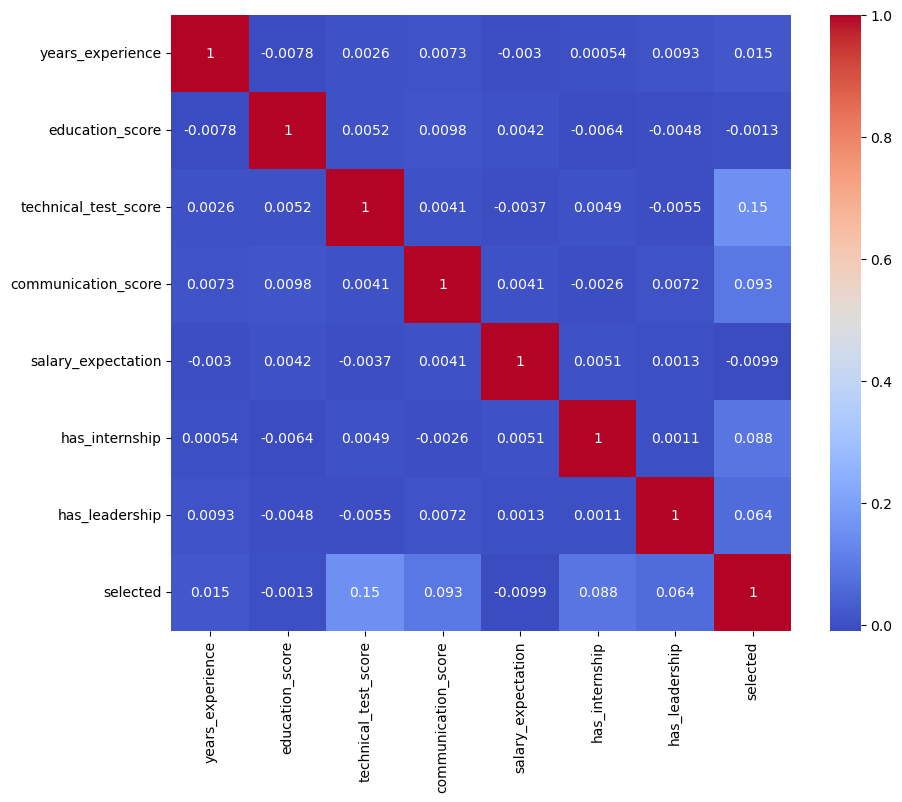

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("job.csv")

# Basic checks
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

# Target distribution
sns.countplot(x="selected", data=df)
plt.show()

# Histograms
df.hist(figsize=(12,10))
plt.show()

# Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [3]:
print(df.skew(numeric_only=True))

# Log transform if skewed
df["salary_expectation"] = np.log1p(df["salary_expectation"])

years_experience        0.037011
education_score         0.004919
technical_test_score   -0.063774
communication_score    -0.009028
salary_expectation      1.281381
has_internship         -0.405880
has_leadership          0.872274
selected                0.872898
dtype: float64


In [4]:
# Select only numerical feature columns (exclude target)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove("selected")  # don't remove based on target

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Filter only numeric columns
df = df[
    ~((df[num_cols] < (Q1 - 1.5 * IQR)) |
      (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("New Shape after Outlier Removal:", df.shape)

New Shape after Outlier Removal: (48656, 9)


In [5]:
df = df.copy()

In [6]:
df.loc[:, "exp_level"] = pd.cut(
    df["years_experience"],
    bins=[0,2,5,10,20],
    labels=["Fresher","Junior","Mid","Senior"]
)

df.loc[:, "salary_exp_ratio"] = (
    df["salary_expectation"] / (df["years_experience"] + 1)
)

df.loc[:, "total_score"] = (
    df["education_score"] +
    df["technical_test_score"] +
    df["communication_score"]
)

In [7]:
from sklearn.feature_selection import mutual_info_classif

X_temp = df.drop("selected", axis=1)
X_temp = pd.get_dummies(X_temp, drop_first=True)

y_temp = df["selected"]

mi = mutual_info_classif(X_temp, y_temp)
mi_scores = pd.Series(mi, index=X_temp.columns)
print(mi_scores.sort_values(ascending=False))

total_score                       0.012706
technical_test_score              0.010983
has_internship                    0.009460
exp_level_Mid                     0.005167
communication_score               0.003848
has_leadership                    0.002782
salary_expectation                0.001949
salary_exp_ratio                  0.001824
education_score                   0.000963
exp_level_Junior                  0.000388
job_role_Digital Marketer         0.000301
job_role_Healthcare Consultant    0.000138
years_experience                  0.000000
job_role_Risk Analyst             0.000000
job_role_Data Scientist           0.000000
job_role_Mechanical Engineer      0.000000
job_role_Financial Analyst        0.000000
exp_level_Senior                  0.000000
dtype: float64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X = df.drop("selected", axis=1)
y = df["selected"]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    print(name, "Accuracy:", pipe.score(X_test, y_test))

Logistic Accuracy: 0.7032470201397452
RandomForest Accuracy: 0.6907110563090835


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100,200],
    "model__max_depth": [None,10,20]
}

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

In [ ]:
probs = best_model.predict_proba(X_test)[:,1]

recommendation_df = X_test.copy()
recommendation_df["probability_of_selection"] = probs

top_candidates = recommendation_df.sort_values(
    by="probability_of_selection",
    ascending=False
).head(10)

top_candidates

In [ ]:
import joblib

joblib.dump(best_model, "job_recommendation_model.pkl")